In [1]:
import sys
print(sys.executable)
print(sys.version)
print(sys.version_info)

C:\Users\dasol\anaconda3\envs\orieEnv3\python.exe
3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]
sys.version_info(major=3, minor=11, micro=5, releaselevel='final', serial=0)


In [1]:
pwd

'C:\\Users\\dasol\\OneDrive - Cornell University\\Projects\\2023-TiltML\\proj\\differentFunctions\\patches\\temp'

In [2]:
from abtem import distributions

In [2]:
import numpy as np
from ase.io import read
from abtem import *
import ase
from datetime import datetime
import matplotlib.pyplot as plt

file:///C:/Users/dasol/OneDrive%20-%20Cornell%20University/Projects/2023-TiltML/proj/Exp/STO/20240116_PACBED.html

http://localhost:8892/notebooks/newAbTEM.ipynb

todo: tds off vs. experiment parameter space plot

In [3]:
atoms = read('./SrTiO3.cif')

In [4]:
import cupy as cp
cp.cuda.Device().use()

<CUDA Device 0>

In [5]:
def normalized(img):
    return (img-np.min(img))/(np.max(img)-np.min(img))

In [8]:
# sc = atoms*(8,8,97);
# sc.center(axis=(0,1),vacuum=10)
# print(sc.cell)

Cell([49.345259825, 49.345259825, 379.53202707])


In [77]:
dx = atoms.cell[2,2] #step in thickness in angstrom

def simulate4(x):
    #----variables----
    #x: thickness in angstrom
    start = datetime.now()
    
    numUC = int(x/dx)#number of unit cells in z direction (variable x)
    #tag = '/vac_conv19p1_volt200kV_tilt0each_{:04d}.tiff'.format(int(numUC*dx))
    sc = atoms * (16,16,numUC) #todo: may need to do the rounding instead
    #sc.center(axis=(0,1),vacuum=10)
    
    #fp = FrozenPhonons(sc,20,{'Sr':.1,'Ti':.1,'O':.1},seed=1)
    #fp = FrozenPhonons(sc,20,{'Sr':.088,'Ti':.0746,'O':.0963},seed=1)
    potential = Potential(sc,gpts=512, projection='infinite',#
                          #sampling=0.15, projection='infinite', #,sampling=0.06
                          slice_thickness= 2,storage  = 'gpu', precalculate=True,
                          device='gpu', parametrization='kirkland')
    probe = Probe(energy=200e3, semiangle_cutoff=19.1,tilt=(20,20),
                  device='gpu')
    probe.grid.match(potential)
    print(probe.cutoff_scattering_angles)
    
    pixelated_detector = PixelatedDetector(max_angle=45) #temporary limit for thickness
 #29.345 33.258 
    gridscan = GridScan(start=[29.345,29.345], end=[33.258 ,33.258],sampling=.3)
    #scan = GridScan(start=[19.7,19.7], end=[27.6,27.6],sampling=.2)

    pixelated_measurement = probe.scan(gridscan, pixelated_detector, potential)
    pacbed = np.mean(pixelated_measurement.array,axis=(0,1))
    
    end = datetime.now() 
    print('Time elapsed (hh:mm:ss.ms):  {}  || thickness: {} $\AA$  || shape: {}'.format(end-start,
                                                                                        numUC*dx,
                                                                                        pacbed.shape))
    return pixelated_measurement, pacbed

### old school way 

In [6]:
from PIL import Image

In [36]:
dx

3.91270131

In [26]:
dx = atoms.cell[2,2] #step in thickness in angstrom
fpath = './sim/'

def simulate(x,tX,tY):
    #----variables----
    #x: thickness in angstrom
    start = datetime.now()
    
    numUC = int(x/dx)#number of unit cells in z direction (variable x)
    tag = '{:04d}.tiff'.format(int(numUC*dx))
    imgPath = 'TiltX_{}_TiltY_{}_Thickness_'.format(int(tX),int(tY)) +tag
    #tag = '/vac_conv19p1_volt200kV_tilt0each_{:04d}.tiff'.format(int(numUC*dx))
    sc = atoms * (16,16,numUC) #todo: may need to do the rounding instead
    #sc.center(axis=(0,1),vacuum=10)
    
    #fp = FrozenPhonons(sc,20,{'Sr':.1,'Ti':.1,'O':.1},seed=1)
    fp = FrozenPhonons(sc,20,{'Sr':.088,'Ti':.0746,'O':.0963},seed=1)
    potential = Potential(fp,gpts=512, projection='infinite',#
                          #sampling=0.15, projection='infinite', #,sampling=0.06
                          slice_thickness= 2,storage  = 'gpu', precalculate=True,
                          device='gpu', parametrization='kirkland')
    probe = Probe(energy=200e3, semiangle_cutoff=19.1,tilt=(tX,tY),
                  device='gpu')
    probe.grid.match(potential)
    #print(probe.cutoff_scattering_angles)
    
    pixelated_detector = PixelatedDetector(max_angle=45) #temporary limit for thickness
 #29.345 33.258 
    gridscan = GridScan(start=[29.345,29.345], end=[33.258 ,33.258],sampling=.3)
    #scan = GridScan(start=[19.7,19.7], end=[27.6,27.6],sampling=.2)

    pixelated_measurement = probe.scan(gridscan, pixelated_detector, potential,pbar=False)
    pacbed = np.mean(pixelated_measurement.array,axis=(0,1))
    
    end = datetime.now() 
    print('Time elapsed (hh:mm:ss.ms):  {}  || thickness: {} $\AA$  || shape: {}'.format(end-start,
                                                                                        numUC*dx,
                                                                                        pacbed.shape))
    #save it before downsizing it
    pacbedImg = Image.fromarray(pacbed.astype(np.float32))
    pacbedImg.save(fpath+imgPath)
    return None #pixelated_measurement, pacbed

In [27]:
simulate(100,10,2)

Time elapsed (hh:mm:ss.ms):  0:00:30.613749  || thickness: 97.81753275 $\AA$  || shape: (227, 227)


In [23]:
np.arange(-12,13,4)

array([-12,  -8,  -4,   0,   4,   8,  12])

In [18]:
np.arange(-10,11,3)

array([-10,  -8,  -6,  -4,  -2,   0,   2,   4,   6,   8])

In [19]:
np.arange(50,500,50)

array([ 50, 100, 150, 200, 250, 300, 350, 400, 450])

In [29]:
from tqdm import tqdm

In [30]:
for itThick in tqdm(np.arange(50,500,50)):
    for itTiltX in np.arange(-12,13,4):
        for itTiltY in np.arange(-12,13,4):
            simulate(itThick,itTiltX,itTiltY)

  0%|                                                                                            | 0/9 [00:00<?, ?it/s]

Time elapsed (hh:mm:ss.ms):  0:00:16.901044  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:16.432598  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:16.729722  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:16.249115  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:16.425158  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:16.711035  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:16.425412  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:15.960666  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:15.923008  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:15.900846  |

 11%|█████████                                                                        | 1/9 [13:14<1:45:53, 794.23s/it]

Time elapsed (hh:mm:ss.ms):  0:00:16.131990  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.194439  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.162013  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.223034  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.141744  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.115477  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.196515  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.230182  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.173322  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.135666  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Tim

 22%|█████████████████▊                                                              | 2/9 [37:57<2:19:58, 1199.76s/it]

...

Time elapsed (hh:mm:ss.ms):  0:01:55.365489  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.474022  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.400932  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.472817  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.581577  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.513902  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.655735  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.470316  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.573324  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.461227  || thickness: 399.09553362 $\AA$  || shape: (227, 227)


 89%|█████████████████████████████████████████████████████████████████████▎        | 8/9 [7:12:01<1:13:14, 4394.13s/it]

Time elapsed (hh:mm:ss.ms):  0:02:09.540237  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:09.680044  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:09.577439  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:09.685424  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:09.655996  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:09.637162  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:09.538117  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:09.486445  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:09.595281  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:09.504430  || thickness: 449.96065065 $\AA$  || shape: (227, 227)


100%|████████████████████████████████████████████████████████████████████████████████| 9/9 [8:58:18<00:00, 3588.67s/it]

Time elapsed (hh:mm:ss.ms):  0:02:09.701666  || thickness: 449.96065065 $\AA$  || shape: (227, 227)


In [31]:
np.arange(-10,11,4)

array([-10,  -6,  -2,   2,   6,  10])

In [32]:
t1 = datetime.now() 

for itThick in tqdm(np.arange(50,500,50)):
    for itTiltX in np.arange(-10,11,4):
        for itTiltY in np.arange(-10,11,4):
            simulate(itThick,itTiltX,itTiltY)
t2 = datetime.now()
print(t2-t1)

  0%|                                                                                            | 0/9 [00:00<?, ?it/s]

Time elapsed (hh:mm:ss.ms):  0:00:16.718595  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:16.140974  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:15.513661  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:15.552835  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:15.774319  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:15.750144  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:15.796936  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:15.933053  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:15.862312  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:16.041103  |

 11%|█████████                                                                        | 1/9 [09:38<1:17:04, 578.03s/it]

Time elapsed (hh:mm:ss.ms):  0:00:16.180200  || thickness: 46.952415720000005 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.260558  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.411973  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.210347  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.221524  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.248976  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.272198  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.207932  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.170826  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:00:30.102710  || thickness: 97.81753275 $\AA$  || shape: (227, 227)
Tim

 22%|██████████████████                                                               | 2/9 [27:51<1:42:49, 881.32s/it]

...

Time elapsed (hh:mm:ss.ms):  0:01:41.762819  || thickness: 348.23041659 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:56.087873  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.944284  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:56.144962  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:56.119206  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:55.999243  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:56.011062  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:56.017597  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:56.051774  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:01:56.038770  || thickness: 399.09553362 $\AA$  || shape: (227, 227)


 89%|███████████████████████████████████████████████████████████████████████         | 8/9 [5:17:57<53:57, 3237.12s/it]

Time elapsed (hh:mm:ss.ms):  0:01:56.012246  || thickness: 399.09553362 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:11.379241  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:11.133650  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:10.191750  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:12.611332  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:11.766479  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:10.226829  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:10.233131  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:10.176335  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
Time elapsed (hh:mm:ss.ms):  0:02:10.276087  || thickness: 449.96065065 $\AA$  || shape: (227, 227)


100%|████████████████████████████████████████████████████████████████████████████████| 9/9 [6:36:10<00:00, 2641.14s/it]

Time elapsed (hh:mm:ss.ms):  0:02:10.064731  || thickness: 449.96065065 $\AA$  || shape: (227, 227)
6:36:10.262012


In [33]:
print(t2-t1)

6:36:10.262012


In [35]:
print(t2)

2025-03-11 18:52:49.789537


In [14]:
img = Image.open('./sim/TiltX_2_TiltY_10_Thickness_0097.tiff')
temp = np.asarray(img).copy()
img.close()

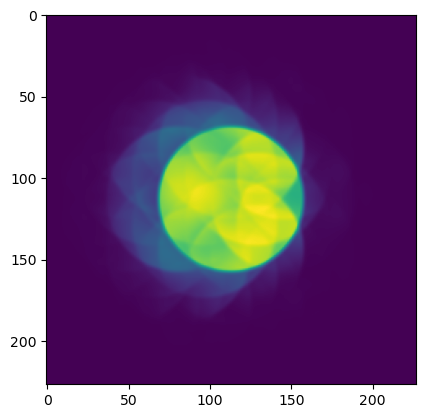

In [15]:
plt.figure()
plt.imshow(temp)

### test

In [80]:
meas5, pac5 = simulate4(500)

(68.30363349975471, 68.30363349975471)


Potential:   0%|          | 0/249 [00:00<?, ?it/s]

Scan:   0%|          | 0/169 [00:00<?, ?it/s]

Time elapsed (hh:mm:ss.ms):  0:00:07.755329  || thickness: 496.91306637 $\AA$  || shape: (227, 227)


In [65]:
meas5, pac5 = simulate4(380)

(68.30363349975471, 68.30363349975471)


Potential:   0%|          | 0/190 [00:00<?, ?it/s]

Scan:   0%|          | 0/169 [00:00<?, ?it/s]

Time elapsed (hh:mm:ss.ms):  0:00:06.099126  || thickness: 379.53202707 $\AA$  || shape: (227, 227)


In [75]:
pac5.shape

(227, 227)

In [60]:
pac5.shape

(177, 177)

In [8]:
meas5, pac5 = simulate4(380)

(0.20001029060702877, 0.20001029060702877)


Potential:   0%|          | 0/190 [00:00<?, ?it/s]

TDS:   0%|          | 0/20 [00:00<?, ?it/s]

Scan:   0%|          | 0/169 [00:00<?, ?it/s]

Time elapsed (hh:mm:ss.ms):  0:01:10.370843  || thickness: 379.53202707 $\AA$  || shape: (171, 171)


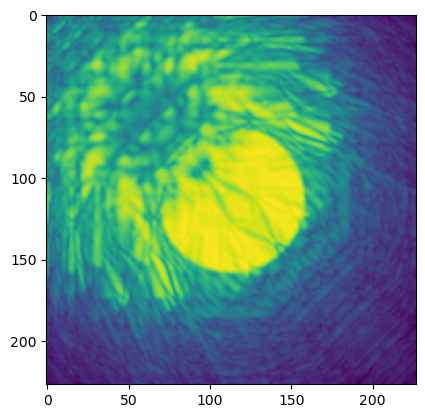

In [81]:
plt.imshow(pac5**0.1)

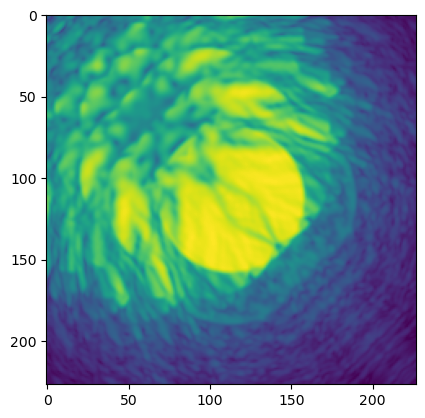

In [79]:
plt.imshow(pac5**0.1)

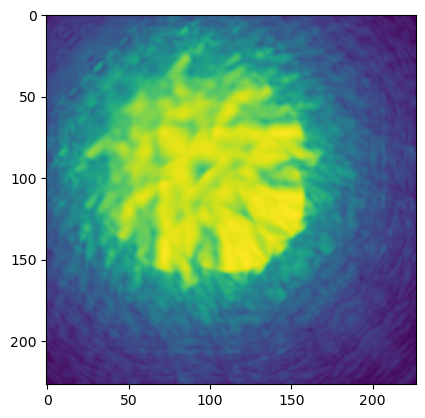

In [67]:
plt.imshow(pac5**0.1)

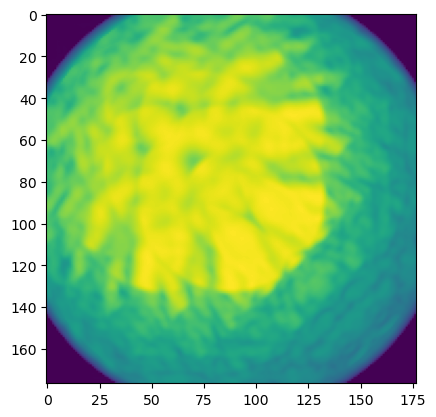

In [38]:
plt.imshow(pac5**0.1)

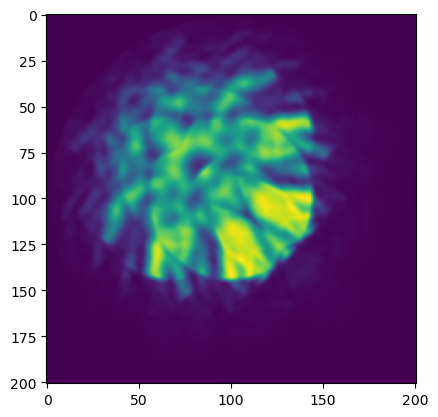

In [25]:
plt.imshow(pac5)

### series

In [14]:
tilt_x.values

array([0.  , 2.25, 4.5 , 6.75, 9.  ])

In [11]:
sc = atoms * (16,16,97) #todo: may need to do the rounding instead

potential = Potential(sc,gpts=512, projection='infinite',#
                      #sampling=0.15, projection='infinite', #,sampling=0.06
                      slice_thickness= 2, #precalculate=True, #storage  = 'gpu',
                      device='gpu', parametrization='kirkland')

tilt_x = distributions.uniform(0, 9.0, 5)

probe_tilt = Probe(
    energy=200e3, semiangle_cutoff=19.1, defocus=0, tilt=(tilt_x, 0.0)
)
probe_tilt.grid.match(potential)

# exit_wave_tilt = probe_tilt.multislice(
#     potential=potential
# )
# exit_wave_tilt.compute()
pixelated_detector = PixelatedDetector(max_angle=45) #temporary limit for thickness
gridscan = GridScan(start=[29.345,29.345], end=[33.258 ,33.258],sampling=.3)

pixelated_measurement = probe_tilt.scan(potential,scan = gridscan,detectors= pixelated_detector)

In [15]:
pixelated_measurement.compute()

[########################################] | 100% Completed | 314.54 s


In [18]:
pixelated_measurement.array.shape

(5, 14, 14, 228, 228)

# archive

In [ ]:
sc = atoms * (16,16,97) #todo: may need to do the rounding instead

potential = Potential(sc,gpts=512, projection='infinite',#
                      #sampling=0.15, projection='infinite', #,sampling=0.06
                      slice_thickness= 2, #precalculate=True, #storage  = 'gpu',
                      device='gpu', parametrization='kirkland')

tilt_x = distributions.uniform(0, 9.0, 5)

probe_tilt = Probe(
    energy=200e3, semiangle_cutoff=19.1, defocus=0, tilt=(tilt_x, 0.0)
)
probe_tilt.grid.match(potential)

# exit_wave_tilt = probe_tilt.multislice(
#     potential=potential
# )
# exit_wave_tilt.compute()
pixelated_detector = PixelatedDetector(max_angle=45) #temporary limit for thickness
gridscan = GridScan(start=[29.345,29.345], end=[33.258 ,33.258],sampling=.3)

pixelated_measurement = probe_tilt.scan(potential,scan = gridscan,detectors= pixelated_detector)

In [ ]:
now = datetime.now()
current_time = now.strftime("%H:%M:%S")
print('Start of paper bethod: ', current_time)


#OOM
print('\n\nkeyword: paper method')
## paper method
potential = Potential(sc, sampling=0.05,projection='infinite', #,sampling=0.06
                          slice_thickness= 0.5,storage  = 'gpu',
                          device='gpu', parametrization='kirkland')
print(potential.sampling)
probe = Probe(energy=200e3, semiangle_cutoff=19.1,tilt=(1.5,-1.5),device='gpu')
probe.grid.match(potential)

detector = PixelatedDetector(max_angle=35) #temporary limit for thickness
scan = GridScan(start=[19.7,19.7], end=[27.6,27.6],sampling=.1)

wave = probe.build(scan.get_positions())
wave = wave.multislice(potential, pbar=False)
measurement = detector.detect(wave) #returns CBED
pacbed = measurement.sum((0)).get() #sum over positions to get PACBED #array
np.save('./paperMethod_potP05_gridP1.npy',pacbed)
pacbed = normalized(pacbed) #normalize 0-1
pacbedImg = Image.fromarray(pacbed.astype(np.float32))
pacbedImg.save('./paperMethod_potP05_gridP1.tiff')

del potential, probe, detector, scan, wave, measurement, pacbed

now = datetime.now()
current_time = now.strftime("%H:%M:%S")
print('Over at: ', current_time)